<h1 style="text-align: center; margin: 0; padding: 20px; background-color: #2a3128; color: white;">AsTorch Quickstart MNIST</h1>

# Project: Training MNIST with AsTorch

### 📝 Overview
This notebook demonstrates the first end-to-end training of a Neural Network using **AsTorch**, a custom deep learning library built from scratch. We will be performing handwritten digit recognition using the classic **MNIST** dataset.


<h1 style="margin: 0; padding: 20px; background-color: #DC143C; color: white; text-align: left;">1. Data Pipeline</h1>


### Import Required Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.metrics import confusion_matrix, accuracy_score
from collections import Counter
import os
import pickle

# AsTorch imports
import AsTorch
from AsTorch import Tensor, no_grad
from AsTorch.data import MNISTDataset, DataLoader, Subset
from AsTorch.nn import Sequential
from AsTorch.nn.modules.layers import Linear
from AsTorch.nn.modules.activations import ReLU, Softmax
from AsTorch.nn.functional.losses import cross_entropy
from AsTorch.optim import SGD, Adam

### Load and Prepare MNIST Dataset

In [2]:
# Load MNIST dataset from keras
from tensorflow import keras

(train_images, train_labels), (test_images, test_labels) = keras.datasets.mnist.load_data()

print(f"Original datasets:")
print(f"  - Training: {train_images.shape} images, {train_labels.shape} labels")
print(f"  - Test: {test_images.shape} images, {test_labels.shape} labels")

# Normalize images to [0, 1]
train_images = train_images.astype(np.float32) / 255.0
test_images = test_images.astype(np.float32) / 255.0

# Create validation set from training data
# Split: 55k train, 5k validation
val_size = 5000
val_images = train_images[:val_size]
val_labels = train_labels[:val_size]
train_images = train_images[val_size:]
train_labels = train_labels[val_size:]

# Use first 5k of test as test set
test_images = test_images[:5000]
test_labels = test_labels[:5000]

print(f"\nAfter split:")
print(f"  - Training: {train_images.shape[0]} samples")
print(f"  - Validation: {val_images.shape[0]} samples")
print(f"  - Test: {test_images.shape[0]} samples")

# Create datasets
train_dataset = MNISTDataset(train_images, train_labels)
val_dataset = MNISTDataset(val_images, val_labels)
test_dataset = MNISTDataset(test_images, test_labels)

Original datasets:
  - Training: (60000, 28, 28) images, (60000,) labels
  - Test: (10000, 28, 28) images, (10000,) labels

After split:
  - Training: 55000 samples
  - Validation: 5000 samples
  - Test: 5000 samples


### Create Data Loaders

In [3]:
# Create DataLoaders
batch_size = 32

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"DataLoaders created:")
print(f"  - Train: {len(train_loader)} batches of {batch_size}")
print(f"  - Val: {len(val_loader)} batches of {batch_size}")
print(f"  - Test: {len(test_loader)} batches of {batch_size}")

# Test one batch
for batch_images, batch_labels in train_loader:
    print(f"\nSample batch shapes:")
    print(f"  - Images: {batch_images.shape}")
    print(f"  - Labels: {batch_labels.shape}")
    break

DataLoaders created:
  - Train: 1719 batches of 32
  - Val: 157 batches of 32
  - Test: 157 batches of 32

Sample batch shapes:
  - Images: (32, 28, 28)
  - Labels: (32,)


<h1 style="margin: 0; padding: 20px; background-color: #DC143C; color: white; text-align: left;">2. Model Architecture</h1>

### Build Neural Network Model

In [4]:
# Build MLP model for MNIST
# Architecture: 784 -> 128 -> 64 -> 10

model = Sequential(
    Linear(784, 128),      
    ReLU(),                
    Linear(128, 64),       
    ReLU(),               
    Linear(64, 10),        
)

# Count parameters
total_params = 0
for param in model.parameters():
    total_params += np.prod(param.shape)

print("=" * 60)
print("MODEL ARCHITECTURE")
print("=" * 60)
print(f"Input size: 784 (28x28 images flattened)")
print(f"Hidden layer 1: 128 neurons + ReLU")
print(f"Hidden layer 2: 64 neurons + ReLU")
print(f"Output layer: 10 neurons (10 classes)")
print(f"\nTotal parameters: {total_params:,}")
print("=" * 60)

# Show layer details
print("\nLayer breakdown:")
layer_num = 0
for i, param in enumerate(model.parameters()):
    layer_num += 1
    print(f"  Layer {layer_num}: shape={param.shape}, params={np.prod(param.shape):,}")

MODEL ARCHITECTURE
Input size: 784 (28x28 images flattened)
Hidden layer 1: 128 neurons + ReLU
Hidden layer 2: 64 neurons + ReLU
Output layer: 10 neurons (10 classes)

Total parameters: 109,386

Layer breakdown:
  Layer 1: shape=(128, 784), params=100,352
  Layer 2: shape=(128,), params=128
  Layer 3: shape=(64, 128), params=8,192
  Layer 4: shape=(64,), params=64
  Layer 5: shape=(10, 64), params=640
  Layer 6: shape=(10,), params=10


<h1 style="margin: 0; padding: 20px; background-color: #DC143C; color: white; text-align: left;">3. Training Loop</h1>

### Define Training and Validation Functions

In [5]:
def train_epoch(model, train_loader, optimizer, device='cpu'):
    
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    
    for batch_idx, (images, labels) in enumerate(train_loader):
    
        images_flat = images.reshape(images.shape[0], -1)
        
        x = Tensor(images_flat, requires_grad=True)
        y_true = labels.astype(np.int64)
        
        logits = model(x)
        
        loss = cross_entropy(logits, Tensor(y_true))
        
        loss.backward()
        
        optimizer.step()
        optimizer.zero_grad()
        
        total_loss += loss.data.item()
        predictions = np.argmax(logits.data, axis=1)
        correct += np.sum(predictions == y_true)
        total += len(y_true)
    
    avg_loss = total_loss / len(train_loader)
    accuracy = 100 * correct / total
    
    return avg_loss, accuracy


def validate(model, val_loader, device='cpu'):
  
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    
    with no_grad():
        for images, labels in val_loader:
            images_flat = images.reshape(images.shape[0], -1)
            x = Tensor(images_flat)
            y_true = labels.astype(np.int64)
            
            logits = model(x)
            loss = cross_entropy(logits, Tensor(y_true))
            
            total_loss += loss.data.item()
            predictions = np.argmax(logits.data, axis=1)
            correct += np.sum(predictions == y_true)
            total += len(y_true)
    
    avg_loss = total_loss / len(val_loader)
    accuracy = 100 * correct / total
    
    return avg_loss, accuracy

### Train and Validate Model

In [6]:
# Setup training
num_epochs = 10
learning_rate = 0.01
optimizer = SGD(model.parameters(), lr=learning_rate)

# Storage for metrics
train_losses = []
train_accs = []
val_accs = []
best_val_acc = 0
best_model_params_path = 'best_model_params.pkl'

print("Starting training...\n")
print(f"{'Epoch':<8} {'Train Loss':<15} {'Train Acc':<15} {'Val Acc':<15}")
print("=" * 60)

# Training loop
for epoch in range(num_epochs):
    # Train
    train_loss, train_acc = train_epoch(model, train_loader, optimizer)
    
    # Validate
    val_loss, val_acc = validate(model, val_loader)
    
    # Store metrics
    train_losses.append(train_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)
    
    # Save best model parameters using state_dict()
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        # Get model state as numpy arrays (picklable)
        state = model.state_dict()
        with open(best_model_params_path, 'wb') as f:
            pickle.dump(state, f)
        save_indicator = "SAVED"
    else:
        save_indicator = ""
    
    print(f"{epoch+1:<8} {train_loss:<15.4f} %{train_acc:<15.2f}% {val_acc:<15.2f} {save_indicator}")

print("=" * 60)
print(f"\n✓ Training completed!")
print(f"  Best validation accuracy: {best_val_acc:.2f}%")

Starting training...

Epoch    Train Loss      Train Acc       Val Acc        
1        1.2491          %66.57          % 87.44           SAVED
2        0.4040          %88.63          % 90.76           SAVED
3        0.3291          %90.69          % 92.12           SAVED
4        0.2882          %91.68          % 92.46           SAVED
5        0.2562          %92.67          % 93.80           SAVED
6        0.2293          %93.48          % 94.30           SAVED
7        0.2066          %94.07          % 94.70           SAVED
8        0.1874          %94.58          % 95.22           SAVED
9        0.1710          %95.11          % 95.76           SAVED
10       0.1566          %95.48          % 95.90           SAVED

✓ Training completed!
  Best validation accuracy: 95.90%


<h1 style="margin: 0; padding: 20px; background-color: #DC143C; color: white; text-align: left;">4. Evaluation</h1>

### Load Best Model and Evaluate on Test Set

In [7]:
# Load best model parameters
with open(best_model_params_path, 'rb') as f:
    best_model_state = pickle.load(f)

# Recreate model with the same architecture
best_model = Sequential(
    Linear(784, 128),
    ReLU(),
    Linear(128, 64),
    ReLU(),
    Linear(64, 10),
)

# Load the saved state into the model
best_model.load_state_dict(best_model_state)

print(f"Best model loaded (best val acc: {best_val_acc:.2f}%)")

# Evaluate on test set and collect predictions
model = best_model
model.eval()

all_predictions = []
all_labels = []
test_loss = 0

with no_grad():
    for images, labels in test_loader:
        images_flat = images.reshape(images.shape[0], -1)
        x = Tensor(images_flat)
        y_true = labels.astype(np.int64)
        
        logits = model(x)
        loss = cross_entropy(logits, Tensor(y_true))
        test_loss += loss.data.item()
        
        # Convert to numpy array
        logits_np = logits.data.asnumpy() if hasattr(logits.data, 'asnumpy') else np.asarray(logits.data)
        predictions = np.argmax(logits_np, axis=1)
        all_predictions.extend(predictions)
        all_labels.extend(y_true)

all_predictions = np.array(all_predictions)
all_labels = np.array(all_labels)

# Test accuracy
test_acc = 100 * accuracy_score(all_labels, all_predictions)
avg_test_loss = test_loss / len(test_loader)

print("\n" + "=" * 60)
print("TEST SET EVALUATION")
print("=" * 60)
print(f"Test Loss: {avg_test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.2f}%")
print("=" * 60)

# Per-class accuracy
print("\nPer-Class Accuracy (for each digit):")
print("-" * 40)
for digit in range(10):
    mask = all_labels == digit
    if mask.sum() > 0:
        class_acc = 100 * accuracy_score(all_labels[mask], all_predictions[mask])
        print(f"  Digit {digit}: {class_acc:.2f}% ({mask.sum()} samples)")
print("-" * 40)

Best model loaded (best val acc: 95.90%)

TEST SET EVALUATION
Test Loss: 0.2056
Test Accuracy: 93.82%

Per-Class Accuracy (for each digit):
----------------------------------------
  Digit 0: 98.70% (460 samples)
  Digit 1: 98.60% (571 samples)
  Digit 2: 95.09% (530 samples)
  Digit 3: 96.20% (500 samples)
  Digit 4: 92.40% (500 samples)
  Digit 5: 90.79% (456 samples)
  Digit 6: 93.72% (462 samples)
  Digit 7: 91.21% (512 samples)
  Digit 8: 89.57% (489 samples)
  Digit 9: 91.35% (520 samples)
----------------------------------------


### Plot Training Metrics

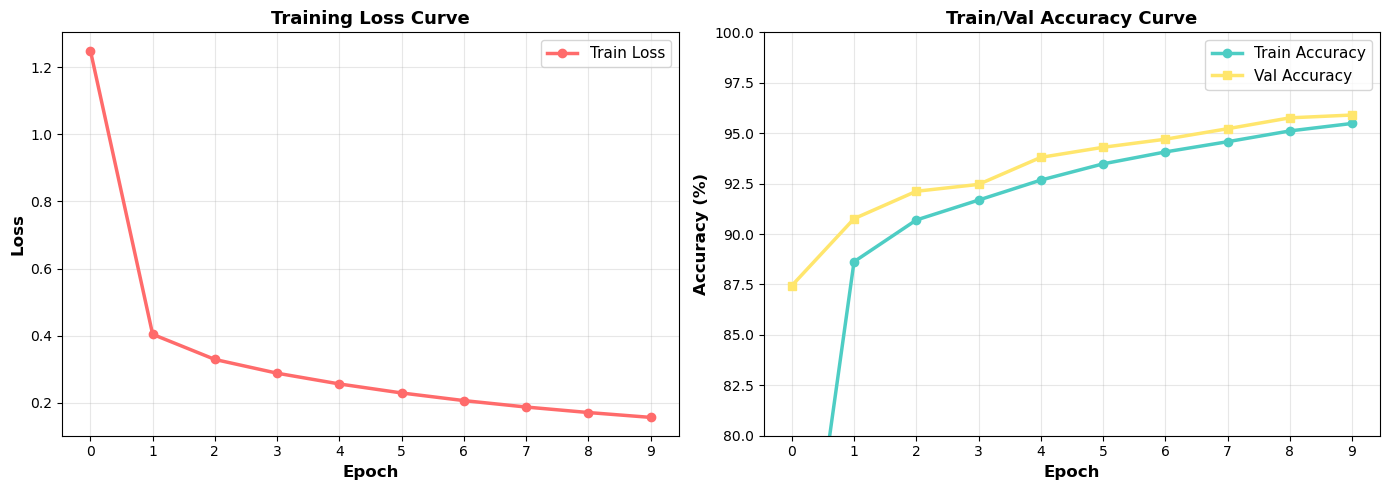

In [8]:
# Create subplots for training metrics
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Training Loss
axes[0].plot(train_losses, linewidth=2.5, color='#FF6B6B', label='Train Loss', marker='o')
axes[0].set_xlabel('Epoch', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Loss', fontsize=12, fontweight='bold')
axes[0].set_title('Training Loss Curve', fontsize=13, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].legend(fontsize=11)
axes[0].set_xticks(range(num_epochs))

# Plot 2: Train/Val Accuracy
axes[1].plot(train_accs, linewidth=2.5, color='#4ECDC4', label='Train Accuracy', marker='o')
axes[1].plot(val_accs, linewidth=2.5, color='#FFE66D', label='Val Accuracy', marker='s')
axes[1].set_xlabel('Epoch', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Accuracy (%)', fontsize=12, fontweight='bold')
axes[1].set_title('Train/Val Accuracy Curve', fontsize=13, fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].legend(fontsize=11)
axes[1].set_xticks(range(num_epochs))
axes[1].set_ylim([80, 100])

plt.tight_layout()
plt.savefig('training_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

<h1 style="margin: 0; padding: 20px; background-color: #DC143C; color: white; text-align: left;">5. Analysis</h1>

### Visualize Correct and Incorrect Predictions

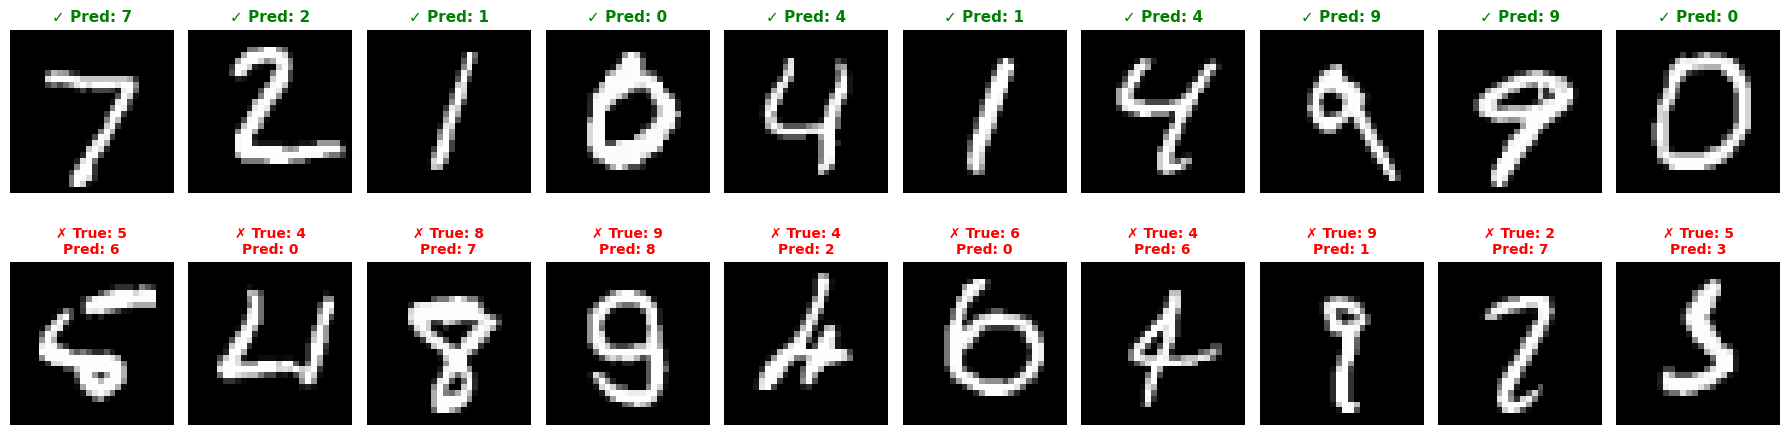

In [9]:
# Get correct and incorrect predictions
correct_mask = all_predictions == all_labels
incorrect_mask = ~correct_mask

correct_indices = np.where(correct_mask)[0]
incorrect_indices = np.where(incorrect_mask)[0]

# Reconstruct test data for visualization
test_images_viz = test_images[:len(all_predictions)]

# Get 10 correct and 10 incorrect predictions
correct_sample_indices = correct_indices[:10]
incorrect_sample_indices = incorrect_indices[:10]

# Create visualization
fig, axes = plt.subplots(2, 10, figsize=(18, 5))

# Plot correct predictions
for i in range(10):
    idx = correct_sample_indices[i]
    image = test_images_viz[idx]
    true_label = all_labels[idx]
    pred_label = all_predictions[idx]
    
    axes[0, i].imshow(image, cmap='gray')
    axes[0, i].set_title(f'✓ Pred: {pred_label}', fontsize=11, fontweight='bold', color='green')
    axes[0, i].axis('off')
    if i == 0:
        axes[0, i].set_ylabel('Correct Predictions', fontsize=12, fontweight='bold', rotation='vertical')

# Plot incorrect predictions
for i in range(10):
    idx = incorrect_sample_indices[i]
    image = test_images_viz[idx]
    true_label = all_labels[idx]
    pred_label = all_predictions[idx]
    
    axes[1, i].imshow(image, cmap='gray')
    axes[1, i].set_title(f'✗ True: {true_label}\nPred: {pred_label}', fontsize=10, fontweight='bold', color='red')
    axes[1, i].axis('off')
    if i == 0:
        axes[1, i].set_ylabel('Incorrect Predictions', fontsize=12, fontweight='bold', rotation='vertical')

plt.tight_layout()
plt.savefig('predictions_visualization.png', dpi=150, bbox_inches='tight')
plt.show()

### Identify Most Confused Class Pairs

MOST CONFUSED CLASS PAIRS

#1: True class 4 → Predicted as 9
     Occurrences: 21 times
     Confusion Rate: 4.20% of all 4s

#2: True class 7 → Predicted as 2
     Occurrences: 18 times
     Confusion Rate: 3.52% of all 7s



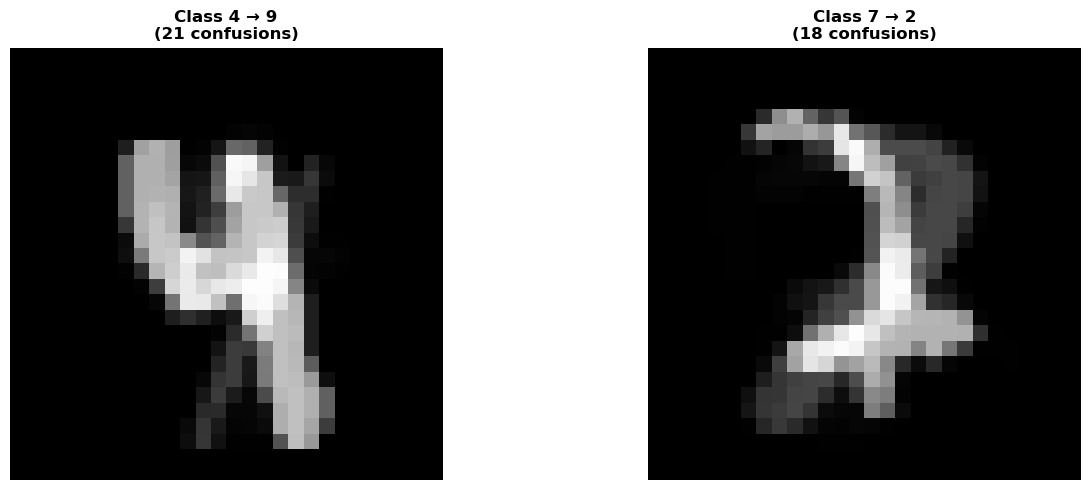

In [10]:
# Compute confusion matrix
conf_matrix = confusion_matrix(all_labels, all_predictions, labels=range(10))

# Find confused class pairs (excluding diagonal)
confusion_pairs = []
for i in range(10):
    for j in range(10):
        if i != j:  # Only off-diagonal elements
            confusion_pairs.append((conf_matrix[i][j], i, j))  # (count, true_label, pred_label)

# Sort by confusion count (descending)
confusion_pairs.sort(reverse=True, key=lambda x: x[0])

# Get top 2 most confused pairs
top_2_pairs = confusion_pairs[:2]

print("=" * 70)
print("MOST CONFUSED CLASS PAIRS")
print("=" * 70)
for rank, (count, true_label, pred_label) in enumerate(top_2_pairs, 1):
    confusion_rate = 100 * count / np.sum(all_labels == true_label)
    print(f"\n#{rank}: True class {true_label} → Predicted as {pred_label}")
    print(f"     Occurrences: {int(count)} times")
    print(f"     Confusion Rate: {confusion_rate:.2f}% of all {true_label}s")

print("\n" + "=" * 70)

# Visualize top confused pairs
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for plot_idx, (count, true_label, pred_label) in enumerate(top_2_pairs):
    # Get samples where true_label was confused with pred_label
    confused_mask = (all_labels == true_label) & (all_predictions == pred_label)
    confused_indices = np.where(confused_mask)[0]
    
    # Display up to 5 examples
    num_examples = min(5, len(confused_indices))
    
    # Create subplot
    ax = axes[plot_idx]
    
    for example_idx in range(num_examples):
        sample_idx = confused_indices[example_idx]
        image = test_images_viz[sample_idx]
        ax.imshow(image, cmap='gray', alpha=0.7)
    
    ax.set_title(f'Class {true_label} → {pred_label}\n({int(count)} confusions)', 
                 fontsize=12, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.savefig('confused_pairs.png', dpi=150, bbox_inches='tight')
plt.show()